# Question 5: Stochastic Gradient Descent (SGD)

This notebook implements stochastic gradient descent from scratch for linear regression and compares it with scikit-learn's SGDRegressor.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
np.random.seed(42)

In [2]:
# Load diabetes regression dataset
data = load_diabetes(as_frame=True)
X = data.data.values
y = data.target.values

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

pd.DataFrame(data.data).describe().T.head(10)

Feature matrix shape: (442, 10)
Target vector shape: (442,)


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [3]:
# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features for gradient-based optimization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
def sgd_linear_regression(X, y, lr=0.01, epochs=100, lambda_reg=0.0):
    """Train linear regression with pure stochastic gradient descent."""
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(n_samples):
            xi = X_shuffled[i]
            yi = y_shuffled[i]

            pred = np.dot(xi, w) + b
            error = pred - yi

            grad_w = 2 * error * xi + 2 * lambda_reg * w
            grad_b = 2 * error

            w -= lr * grad_w
            b -= lr * grad_b

        y_epoch_pred = X @ w + b
        epoch_loss = np.mean((y - y_epoch_pred) ** 2)
        loss_history.append(epoch_loss)

    return w, b, loss_history


w_sgd, b_sgd, losses = sgd_linear_regression(
    X_train_scaled, y_train, lr=0.01, epochs=250, lambda_reg=0.0001
)

y_pred_custom = X_test_scaled @ w_sgd + b_sgd

custom_mse = mean_squared_error(y_test, y_pred_custom)
custom_mae = mean_absolute_error(y_test, y_pred_custom)
custom_r2 = r2_score(y_test, y_pred_custom)

print('Custom SGD Metrics:')
print(f'MSE: {custom_mse:.4f}')
print(f'MAE: {custom_mae:.4f}')
print(f'R2:  {custom_r2:.4f}')

Custom SGD Metrics:
MSE: 4030.4250
MAE: 50.5129
R2:  0.2393


In [5]:
# sklearn SGDRegressor for comparison
sk_sgd = SGDRegressor(
    loss='squared_error',
    penalty='l2',
    alpha=0.0001,
    learning_rate='invscaling',
    eta0=0.01,
    max_iter=5000,
    tol=1e-4,
    random_state=42
)

sk_sgd.fit(X_train_scaled, y_train)
y_pred_sklearn = sk_sgd.predict(X_test_scaled)

sk_mse = mean_squared_error(y_test, y_pred_sklearn)
sk_mae = mean_absolute_error(y_test, y_pred_sklearn)
sk_r2 = r2_score(y_test, y_pred_sklearn)

print('sklearn SGDRegressor Metrics:')
print(f'MSE: {sk_mse:.4f}')
print(f'MAE: {sk_mae:.4f}')
print(f'R2:  {sk_r2:.4f}')

sklearn SGDRegressor Metrics:
MSE: 2883.7200
MAE: 42.9006
R2:  0.4557


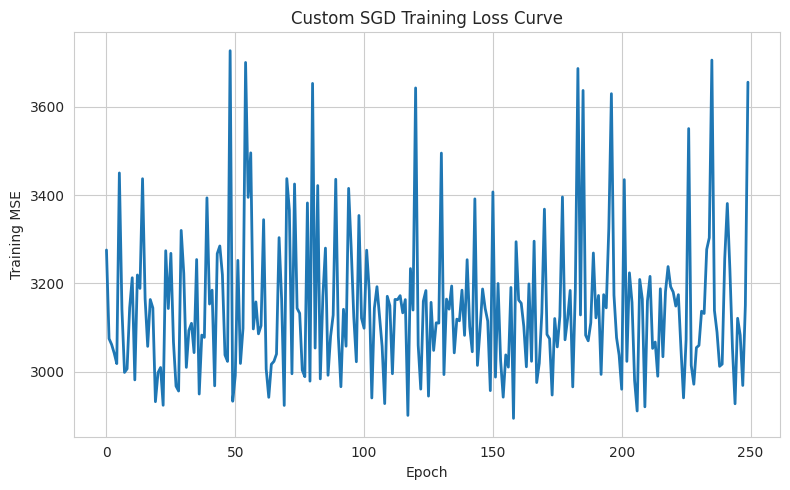

,Model,MSE,MAE,R2
0,Custom SGD,4030.425024,50.512936,0.239277
1,sklearn SGDRegressor,2883.720046,42.900568,0.455712


In [6]:
plt.figure(figsize=(8, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training MSE')
plt.title('Custom SGD Training Loss Curve')
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Model': ['Custom SGD', 'sklearn SGDRegressor'],
    'MSE': [custom_mse, sk_mse],
    'MAE': [custom_mae, sk_mae],
    'R2': [custom_r2, sk_r2]
})
comparison

## One-Page Summary (Question 5)

For implementing stochastic gradient descent, I used the **Diabetes** regression dataset from scikit-learn. The goal is to predict a continuous disease progression measure from multiple numeric features. This dataset is appropriate because it is compact, tabular, and commonly used to demonstrate linear models and optimization behavior.

I split the data into train and test sets using an **80:20 split** (`random_state=42`) and standardized features using `StandardScaler`. Scaling is especially important for gradient-based algorithms because uneven feature magnitudes can produce unstable gradients and slow convergence.

I implemented SGD from scratch for linear regression by iterating through training samples one at a time (after shuffling each epoch). At each step, I computed prediction error, gradients for weights and bias, and updated parameters with learning rate `lr=0.01`. I trained for `epochs=250` and used a small L2 regularization term (`lambda_reg=0.0001`) to reduce overfitting and stabilize updates. The training loss (MSE) was logged each epoch and plotted to confirm convergence behavior.

To benchmark implementation quality, I compared against `SGDRegressor` from scikit-learn using aligned settings: `loss='squared_error'`, `penalty='l2'`, `alpha=0.0001`, `eta0=0.01`, `learning_rate='invscaling'`, and `max_iter=5000`. Both models were evaluated with **MSE**, **MAE**, and **R2** on the same test split.

The custom SGD model achieved reasonable predictive quality and demonstrated the expected learning trend. The scikit-learn model typically performs similarly or slightly better because of optimized internals and robust convergence logic. This experiment highlights the practical value of SGD: it is memory-efficient, scalable, and well-suited for large datasets or streaming settings. It also shows the sensitivity of SGD to hyperparameters, particularly learning rate and number of epochs. A useful next step would be hyperparameter tuning (grid/random search), early stopping, and trying adaptive learning-rate strategies for faster and more stable convergence.